In [2]:
import pandas as pd
import numpy as np

In [3]:
# till now
# Timestamp
print(pd.Timestamp("10/10/2026 8:10"))
# DatetimeIndex -> df and series index
print(pd.DatetimeIndex([pd.Timestamp("10/10/2026 8:10"),pd.Timestamp("11/10/2026 8:10"),pd.Timestamp("13/10/2026 8:10")]))
# date_range()
print(pd.date_range(start="2026-9-10",end="2026-9-14",freq='D'))
# to_datetime()
s=pd.Series(['2026-09-09','2026-09-10', '2026-09-11', '2026-09-12', '2026-09-13'])
pd.to_datetime(s)

2026-10-10 08:10:00
DatetimeIndex(['2026-10-10 08:10:00', '2026-11-10 08:10:00',
               '2026-10-13 08:10:00'],
              dtype='datetime64[us]', freq=None)
DatetimeIndex(['2026-09-10', '2026-09-11', '2026-09-12', '2026-09-13',
               '2026-09-14'],
              dtype='datetime64[us]', freq='D')


0   2026-09-09
1   2026-09-10
2   2026-09-11
3   2026-09-12
4   2026-09-13
dtype: datetime64[us]

### Timedelta Object

Represents a duration, the difference between two dates or times.

In [4]:
# create using Timestamp objects
t1=pd.Timestamp('10th sep 2026 10:09')
t2=pd.Timestamp('10th oct 2026 10:09')
t2-t1

Timedelta('30 days 00:00:00')

In [5]:
# standalone creation
pd.Timedelta(days=2,hours=10,minutes=9)

Timedelta('2 days 10:09:00')

In [6]:
# Arithmetic
pd.Timestamp('10th sep 2026')+pd.Timedelta(days=2,hours=10,minutes=9)

Timestamp('2026-09-12 10:09:00')

In [7]:
pd.date_range(start='2026-09-09',end='2026-09-18',freq='D')+pd.Timedelta(days=2,hours=10,minutes=9)

DatetimeIndex(['2026-09-11 10:09:00', '2026-09-12 10:09:00',
               '2026-09-13 10:09:00', '2026-09-14 10:09:00',
               '2026-09-15 10:09:00', '2026-09-16 10:09:00',
               '2026-09-17 10:09:00', '2026-09-18 10:09:00',
               '2026-09-19 10:09:00', '2026-09-20 10:09:00'],
              dtype='datetime64[us]', freq='D')

In [8]:
# real life example
df=pd.read_csv('deliveries_date.csv')
df

,order_date,delivery_date
0,5/24/98,2/5/99
1,4/22/92,3/6/98
2,2/10/91,8/26/92
3,7/21/92,11/20/97
4,9/2/93,6/10/98
...,...,...
496,6/24/91,2/2/96
497,9/9/91,3/30/98
498,11/16/90,4/27/98
499,6/3/93,6/13/93


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   order_date     501 non-null    str  
 1   delivery_date  501 non-null    str  
dtypes: str(2)
memory usage: 14.7 KB


In [10]:
df['delivery_date']=pd.to_datetime(df['delivery_date'])
df['order_date']=pd.to_datetime(df['order_date'])

C:\Users\ankit\AppData\Local\Temp\ipykernel_19580\2333050219.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivery_date']=pd.to_datetime(df['delivery_date'])
C:\Users\ankit\AppData\Local\Temp\ipykernel_19580\2333050219.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date']=pd.to_datetime(df['order_date'])


In [11]:
df['delivery_time_period']=df['delivery_date']-df['order_date']
df.head()

,order_date,delivery_date,delivery_time_period
0,1998-05-24,1999-02-05,257 days
1,1992-04-22,1998-03-06,2144 days
2,1991-02-10,1992-08-26,563 days
3,1992-07-21,1997-11-20,1948 days
4,1993-09-02,1998-06-10,1742 days


In [12]:
df['delivery_time_period'].mean()

Timedelta('1217 days 22:53:53.532934')

### Time series

A time series is a data set that tracks a sample over time. In particular, a time series allows one to see what factors influence certain variables from period to period. Time series analysis can be useful to see how a given asset, security, or economic variable changes over time.

Examples

- Financial Data (Company stocks)
- Natural Data (Rainfall measurement)
- Event Data (Covid)
- Medical Data (Heart rate monitoring)

Types of Operations done on Time Series

- Time Series Analysis
- Time Series Forecasting

In [13]:
google=pd.read_csv('google.csv')
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
1,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
3,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
4,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276


In [14]:
google.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
4466,2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
4467,2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
4468,2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100
4469,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600
4470,2022-05-20,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100


In [15]:
google.info()

<class 'pandas.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4471 non-null   str    
 1   Open       4471 non-null   float64
 2   High       4471 non-null   float64
 3   Low        4471 non-null   float64
 4   Close      4471 non-null   float64
 5   Adj Close  4471 non-null   float64
 6   Volume     4471 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 288.3 KB


In [16]:
google['Date']=pd.to_datetime(google['Date'])
google.info()

<class 'pandas.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4471 non-null   datetime64[us]
 1   Open       4471 non-null   float64       
 2   High       4471 non-null   float64       
 3   Low        4471 non-null   float64       
 4   Close      4471 non-null   float64       
 5   Adj Close  4471 non-null   float64       
 6   Volume     4471 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 244.6 KB


In [17]:
google.set_index('Date',inplace=True)

In [18]:
# fetch a specific date
google.loc['2022-05-16']

Open         2.307680e+03
High         2.332150e+03
Low          2.286700e+03
Close        2.295850e+03
Adj Close    2.295850e+03
Volume       1.164100e+06
Name: 2022-05-16 00:00:00, dtype: float64

In [19]:
# partial indexing -> select a particular year/month
google.loc['2022-01']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-03,2889.510010,2911.000000,2870.050049,2901.489990,2901.489990,1260700
2022-01-04,2911.010010,2932.199951,2876.322998,2888.330078,2888.330078,1146400
2022-01-05,2883.620117,2885.959961,2750.469971,2753.070068,2753.070068,2482100
2022-01-06,2749.949951,2793.719971,2735.270020,2751.020020,2751.020020,1452500
2022-01-07,2758.100098,2765.094971,2715.780029,2740.090088,2740.090088,970400
2022-01-10,2701.979980,2772.800049,2662.810059,2771.479980,2771.479980,1704800
2022-01-11,2763.610107,2806.590088,2736.270020,2800.350098,2800.350098,1175100
2022-01-12,2831.090088,2856.284912,2822.239990,2832.959961,2832.959961,1182100
2022-01-13,2836.810059,2863.709961,2778.280029,2782.620117,2782.620117,1328300


In [20]:
# create year month-name and day-name
google['month']=google.index.month_name()
google['weekday_name']=google.index.day_name()
google['quarter']=google.index.quarter

In [21]:
google.head()

,Open,High,Low,Close,Adj Close,Volume,month,weekday_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday,3
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3


In [22]:
# slicing
google.loc['2004-08-19 ':'2004-08-29']

,Open,High,Low,Close,Adj Close,Volume,month,weekday_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday,3
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3
2004-08-26,52.279045,53.773445,52.134586,53.753517,53.753517,7128620,August,Thursday,3
2004-08-27,53.848164,54.107193,52.647663,52.876804,52.876804,6241307,August,Friday,3


In [23]:
google.loc['2004-08-19 ':'2004-08-29':2]

,Open,High,Low,Close,Adj Close,Volume,month,weekday_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3
2004-08-27,53.848164,54.107193,52.647663,52.876804,52.876804,6241307,August,Friday,3


In [24]:
# challenge -> fetch info for a particular date every year -> limitation of timedelta
pd.date_range(start='2005-1-6',end='2022-1-6',freq=pd.DateOffset(years=1))


DatetimeIndex(['2005-01-06', '2006-01-06', '2007-01-06', '2008-01-06',
               '2009-01-06', '2010-01-06', '2011-01-06', '2012-01-06',
               '2013-01-06', '2014-01-06', '2015-01-06', '2016-01-06',
               '2017-01-06', '2018-01-06', '2019-01-06', '2020-01-06',
               '2021-01-06', '2022-01-06'],
              dtype='datetime64[us]', freq='<DateOffset: years=1>')

In [25]:
google[google.index.isin(pd.date_range(start='2005-1-6',end='2022-1-6',freq=pd.DateOffset(years=1)))]

,Open,High,Low,Close,Adj Close,Volume,month,weekday_name,quarter
Date,,,,,,,,,
2005-01-06,97.175758,97.584229,93.509506,93.922951,93.922951,20852067,January,Thursday,1
2006-01-06,227.581970,234.371521,225.773743,231.960556,231.960556,35646914,January,Friday,1
2009-01-06,165.868286,169.763687,162.585587,166.406265,166.406265,12898566,January,Tuesday,1
2010-01-06,311.761444,311.761444,302.047852,302.994293,302.994293,7987226,January,Wednesday,1
2011-01-06,304.199799,308.060303,303.885956,305.604523,305.604523,4131026,January,Thursday,1
2012-01-06,328.344299,328.767700,323.681763,323.796326,323.796326,5405987,January,Friday,1
2014-01-06,554.426880,557.340942,551.154114,556.573853,556.573853,3551864,January,Monday,1
2015-01-06,513.589966,514.761719,499.678131,500.585632,500.585632,2899940,January,Tuesday,1
2016-01-06,730.000000,747.179993,728.919983,743.619995,743.619995,1947000,January,Wednesday,1


<Axes: xlabel='Date'>

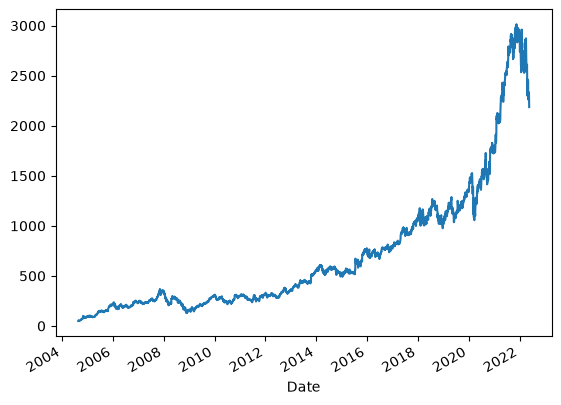

In [26]:
# viz a single col
google['Close'].plot()

In [27]:
google.sample()

,Open,High,Low,Close,Adj Close,Volume,month,weekday_name,quarter
Date,,,,,,,,,
2005-06-30,146.620438,148.90686,144.976593,146.525787,146.525787,30301955,June,Thursday,2


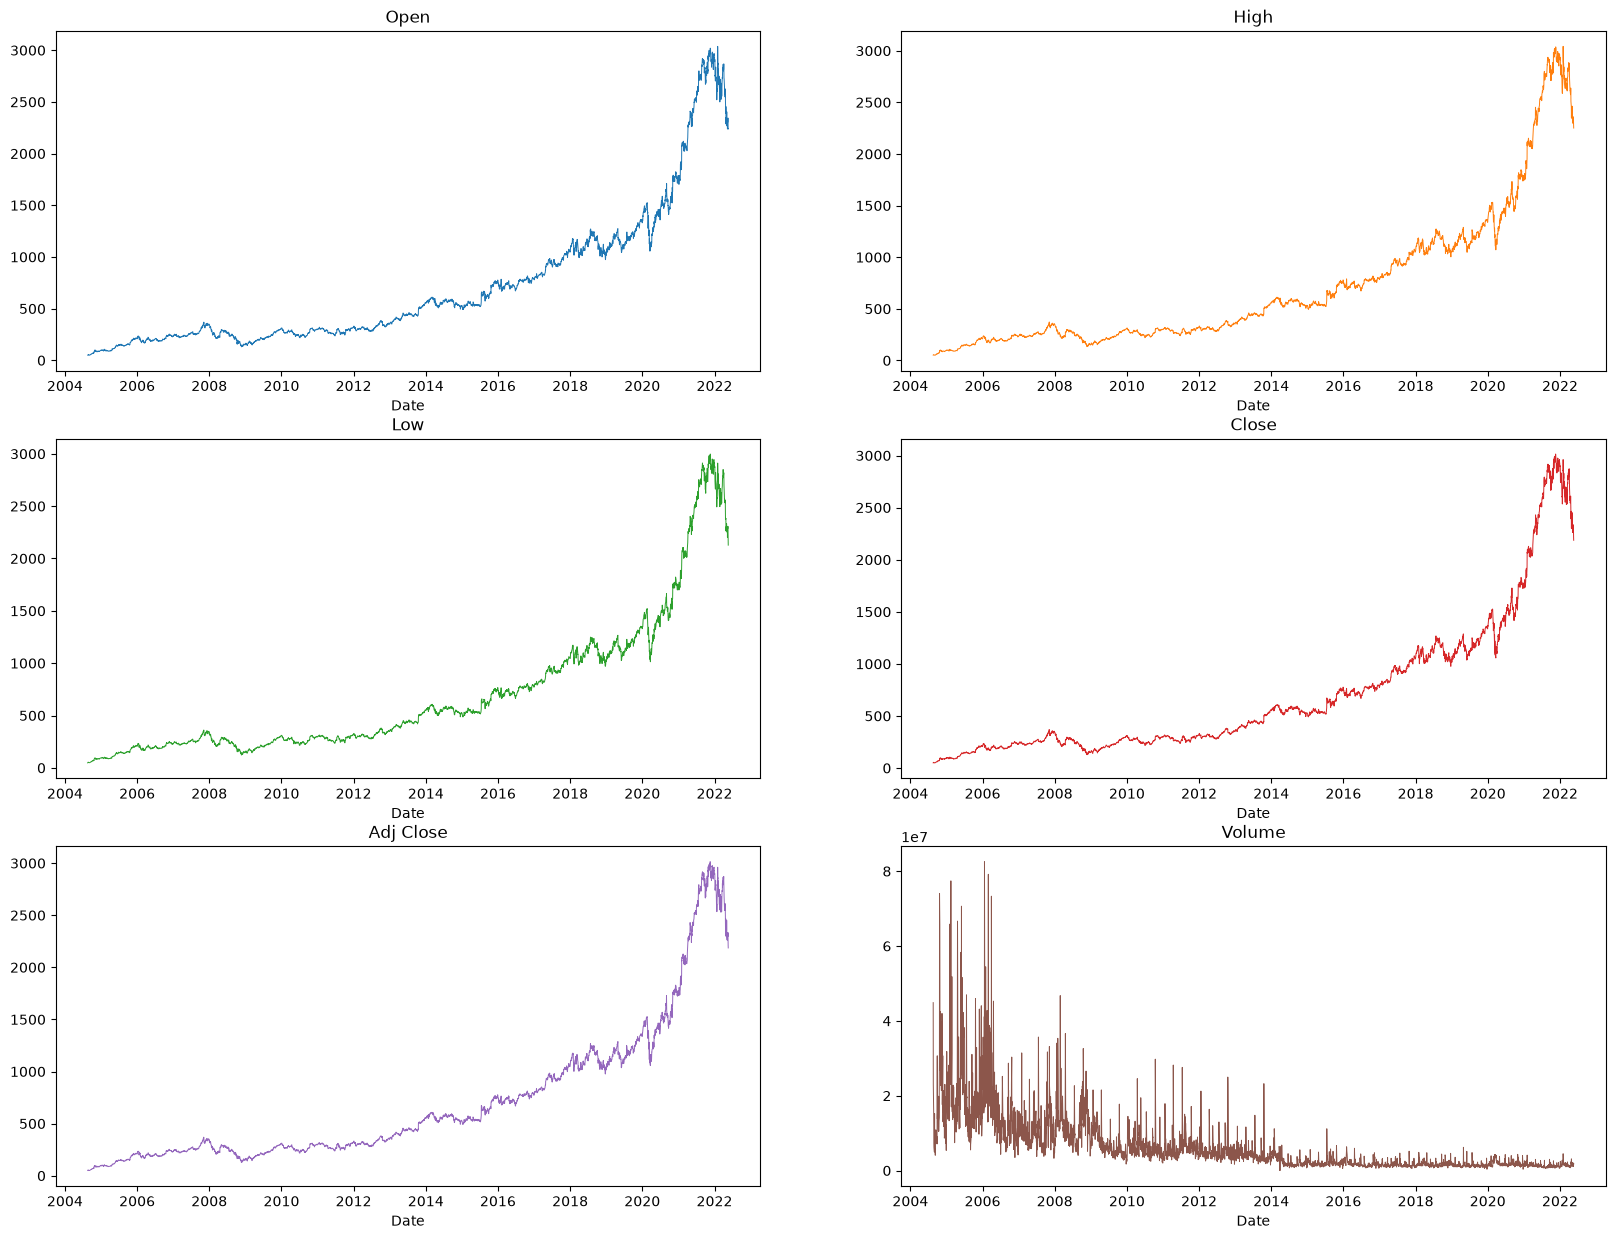

In [28]:
# viz all cols together
df=google[['Open','High','Low','Close','Adj Close','Volume']]
ax=df.plot(subplots=True,layout=(3,2),sharex=False,sharey=False,linewidth=0.7,fontsize=10,legend=False,figsize=(20,15),title=['Open','High','Low','Close','Adj Close','Volume'])

<Axes: xlabel='Date'>

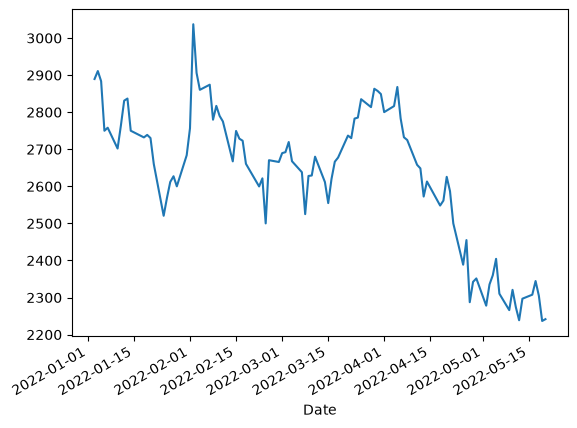

In [29]:
# plot for a particular year/month/week
google.loc['2022']['Open'].plot()

<Axes: xlabel='Date'>

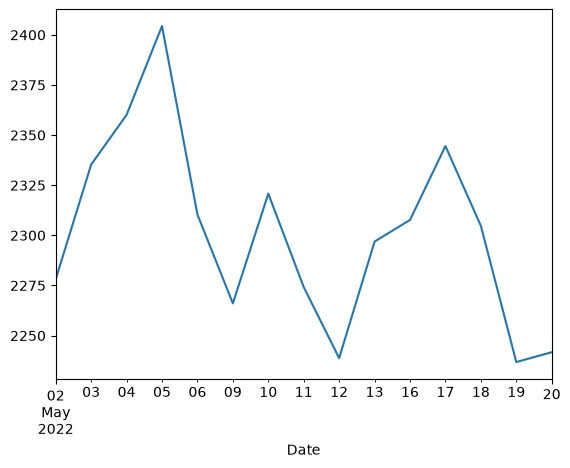

In [30]:
google.loc['2022-5']['Open'].plot()

<Axes: xlabel='month'>

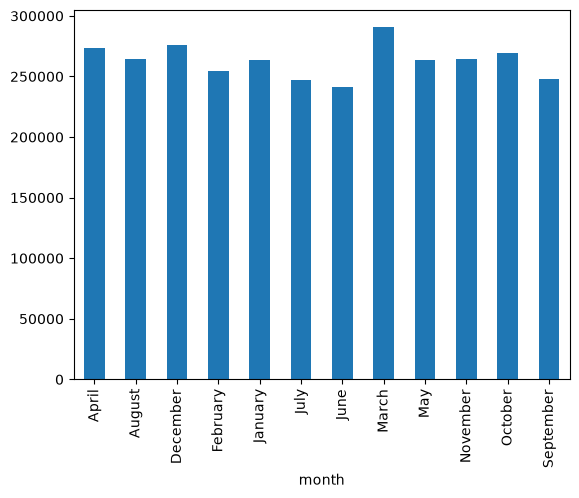

In [31]:
# monthly trend
google.groupby('month')['Open'].sum().plot(kind='bar')

<Axes: xlabel='weekday_name'>

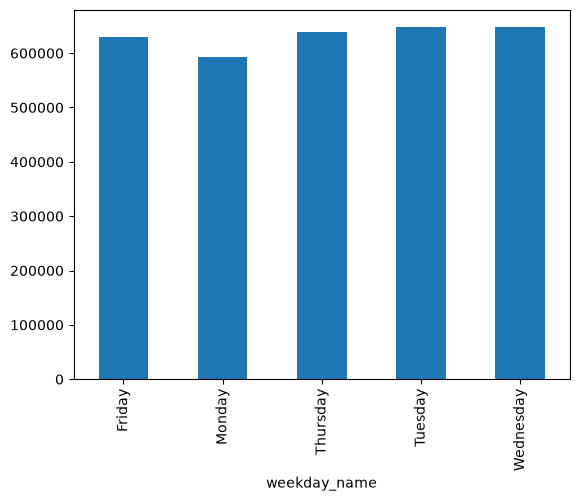

In [32]:
google.groupby('weekday_name')['Open'].sum().plot(kind='bar')

<Axes: xlabel='Date'>

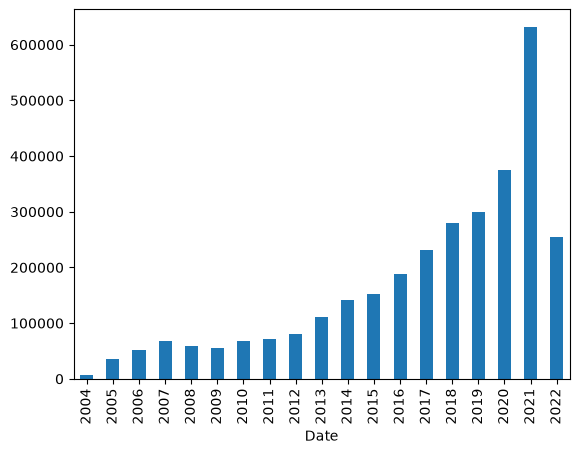

In [33]:
# yearly trend
google.groupby(google.index.year)['Open'].sum().plot(kind='bar')

<Axes: xlabel='Date'>

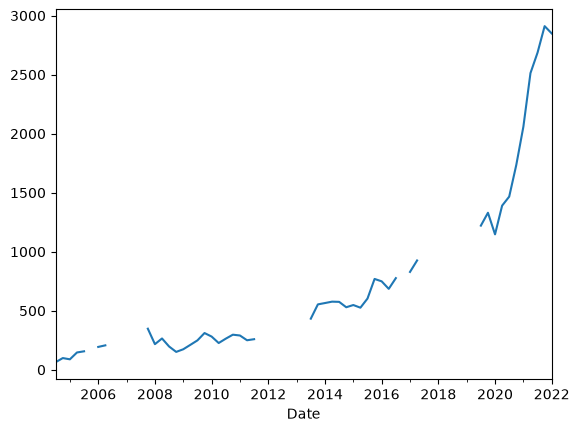

In [34]:
# quaterly trend
google['Open'].asfreq('QE').plot()

<Axes: xlabel='Date'>

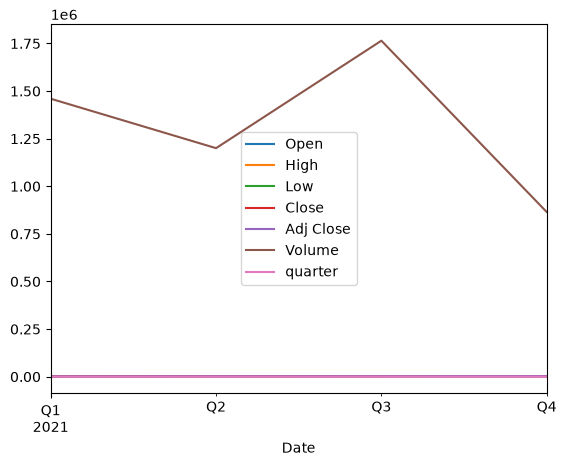

In [35]:
google.loc['2021'].asfreq('QE').plot()

<Axes: xlabel='quarter'>

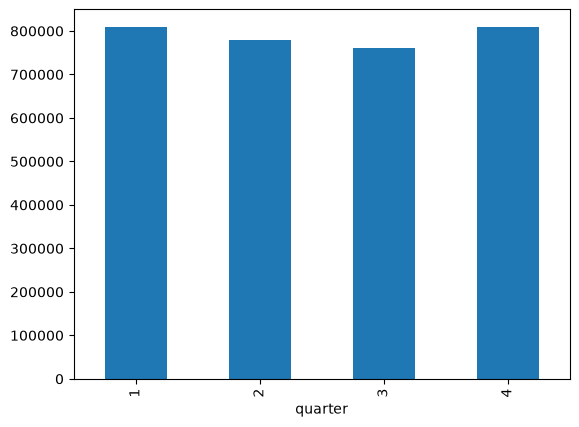

In [36]:
google.groupby('quarter')['Open'].sum().plot(kind='bar')

In [37]:
# frequency
google.index

DatetimeIndex(['2004-08-19', '2004-08-20', '2004-08-23', '2004-08-24',
               '2004-08-25', '2004-08-26', '2004-08-27', '2004-08-30',
               '2004-08-31', '2004-09-01',
               ...
               '2022-05-09', '2022-05-10', '2022-05-11', '2022-05-12',
               '2022-05-13', '2022-05-16', '2022-05-17', '2022-05-18',
               '2022-05-19', '2022-05-20'],
              dtype='datetime64[us]', name='Date', length=4471, freq=None)

In [38]:
# asfreq
google.asfreq('QE')

,Open,High,Low,Close,Adj Close,Volume,month,weekday_name,quarter
Date,,,,,,,,,
2004-09-30,64.707458,65.902977,64.259140,64.558022,64.558022,13823420.0,September,Thursday,3.0
2004-12-31,99.243011,99.566795,95.920464,96.035034,96.035034,15394487.0,December,Friday,4.0
2005-03-31,88.642746,90.356323,88.488327,89.917969,89.917969,13587941.0,March,Thursday,1.0
2005-06-30,146.620438,148.906860,144.976593,146.525787,146.525787,30301955.0,June,Thursday,2.0
2005-09-30,156.523315,158.157181,155.561920,157.639130,157.639130,18371203.0,September,Friday,3.0
...,...,...,...,...,...,...,...,...,...
2021-03-31,2059.120117,2093.326904,2056.745117,2068.629883,2068.629883,1459900.0,March,Wednesday,1.0
2021-06-30,2513.071045,2516.000000,2495.149902,2506.320068,2506.320068,1200300.0,June,Wednesday,2.0
2021-09-30,2686.500000,2711.800049,2660.000000,2665.310059,2665.310059,1764700.0,September,Thursday,3.0


### Resampling

Resampling involves changing the frequency of your time series observations.

Two types of resampling are:

**Upsampling**: Where you increase the frequency of the samples, such as from minutes to seconds.<br>
**Downsampling**: Where you decrease the frequency of the samples, such as from days to months.

<Axes: xlabel='Date'>

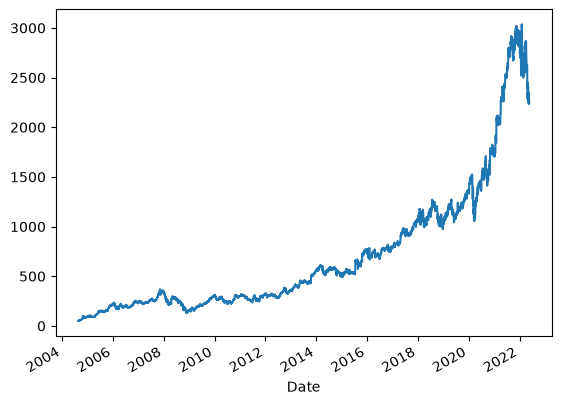

In [39]:
# Downsampling 
google['Open'].plot()

<Axes: xlabel='Date'>

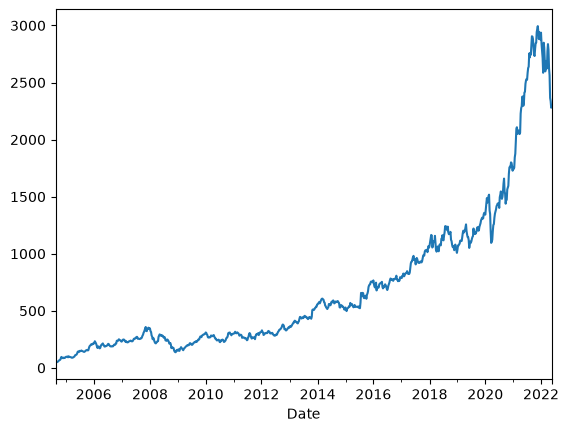

In [40]:
google['Open'].resample('W').mean().plot()

<Axes: xlabel='Date'>

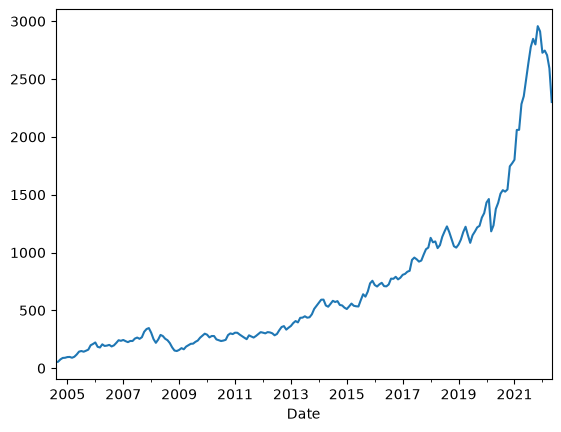

In [41]:
google['Open'].resample('ME').mean().plot()

<Axes: xlabel='Date'>

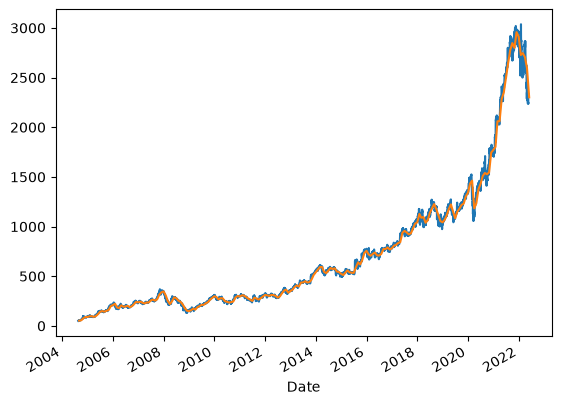

In [42]:
google['Open'].plot()
google['Open'].resample('ME').mean().plot()

<Axes: xlabel='Date'>

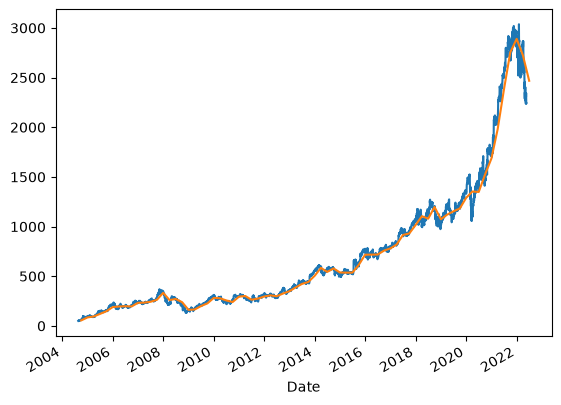

In [43]:
google['Open'].plot()
google['Open'].resample('QE').mean().plot()

<Axes: xlabel='Date'>

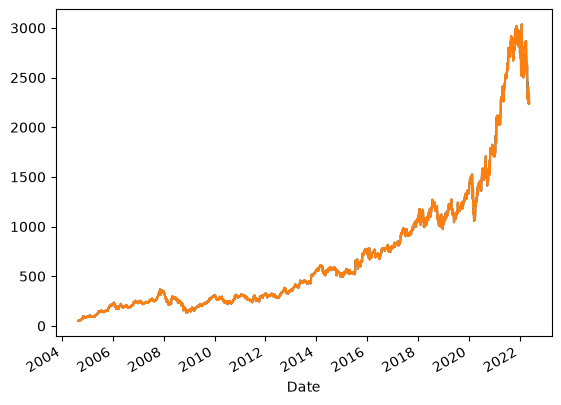

In [44]:
# Upsampling
google['Open'].plot()
google['Open'].resample('h').interpolate(method='linear').plot()

### Rolling Window(Smoothing)
Time series data in original format can be quite volatile, especially on smaller aggregation levels. The concept of rolling, or moving averages is a useful technique for smoothing time series data.

<Axes: xlabel='Date'>

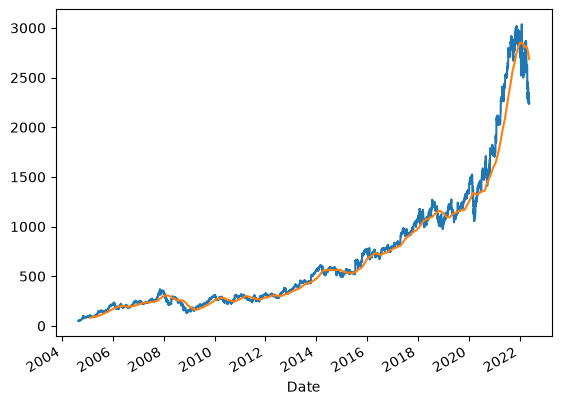

In [45]:
# Rolling window
google['Open'].plot()
google['Open'].rolling(120).mean().plot()

<Axes: xlabel='Date'>

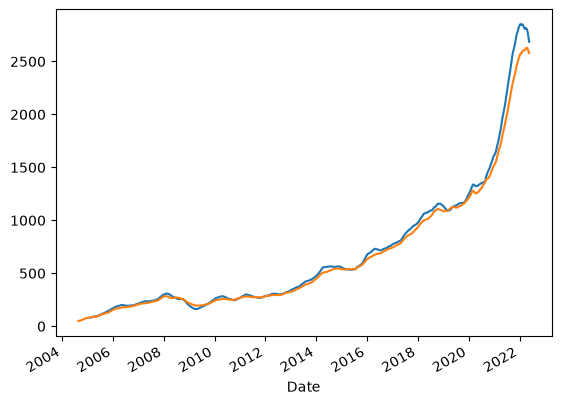

In [46]:

google['Open'].rolling(120).mean().plot()
google['Open'].ewm(120).mean().plot()

### Shifting

The shift() function is Pandas is used to, well, shift the entire series up or down by the desired number of periods.

In [47]:
# shift
google['Open']

Date
2004-08-19      49.813290
2004-08-20      50.316402
2004-08-23      55.168217
2004-08-24      55.412300
2004-08-25      52.284027
                 ...     
2022-05-16    2307.679932
2022-05-17    2344.550049
2022-05-18    2304.750000
2022-05-19    2236.820068
2022-05-20    2241.709961
Name: Open, Length: 4471, dtype: float64

In [48]:
google['Open'].shift(1)

Date
2004-08-19            NaN
2004-08-20      49.813290
2004-08-23      50.316402
2004-08-24      55.168217
2004-08-25      55.412300
                 ...     
2022-05-16    2296.909912
2022-05-17    2307.679932
2022-05-18    2344.550049
2022-05-19    2304.750000
2022-05-20    2236.820068
Name: Open, Length: 4471, dtype: float64

In [49]:
google['Open'].shift(-1)

Date
2004-08-19      50.316402
2004-08-20      55.168217
2004-08-23      55.412300
2004-08-24      52.284027
2004-08-25      52.279045
                 ...     
2022-05-16    2344.550049
2022-05-17    2304.750000
2022-05-18    2236.820068
2022-05-19    2241.709961
2022-05-20            NaN
Name: Open, Length: 4471, dtype: float64

In [51]:
# shift example
df=pd.read_csv('login.csv',header=None)
df=df[[1,2]]
df.rename(columns={1:'user_id',2:'login_time'},inplace=True)
df

,user_id,login_time
0,466,2017-01-07 18:24:07
1,466,2017-01-07 18:24:55
2,458,2017-01-07 18:25:18
3,458,2017-01-07 18:26:21
4,592,2017-01-07 19:09:59
...,...,...
2998,1307,2018-01-04 10:48:28
2999,1230,2018-01-04 11:22:00
3000,1307,2018-01-04 13:13:44
3001,1307,2018-01-04 13:13:45


In [54]:
user_df=df[df['user_id']==413]
user_df.head()

,user_id,login_time
11,413,2017-01-09 12:29:25
12,413,2017-01-09 12:40:39
14,413,2017-01-09 14:08:04
33,413,2017-01-10 14:36:23
35,413,2017-01-10 15:22:45


In [56]:
user_df['login_time']=pd.to_datetime(user_df['login_time'])
user_df.info()

<class 'pandas.DataFrame'>
Index: 222 entries, 11 to 2997
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     222 non-null    int64         
 1   login_time  222 non-null    datetime64[us]
dtypes: datetime64[us](1), int64(1)
memory usage: 5.2 KB


In [57]:
user_df['shifted']=user_df['login_time'].shift(1)
user_df.head()

,user_id,login_time,shifted
11,413,2017-01-09 12:29:25,NaT
12,413,2017-01-09 12:40:39,2017-01-09 12:29:25
14,413,2017-01-09 14:08:04,2017-01-09 12:40:39
33,413,2017-01-10 14:36:23,2017-01-09 14:08:04
35,413,2017-01-10 15:22:45,2017-01-10 14:36:23


In [59]:
(user_df['login_time']-user_df['shifted']).mean()

Timedelta('1 days 15:05:13.384615')